# PRISM Mean Temperature — Feb 2026, Contiguous US

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND
from load_prism import load_prism_torch

In [2]:
# Load data
x, y = load_prism_torch(n_sub=500_000)
# x, y = load_prism_torch()
print(f"x shape: {x.shape}")  # (N, 2) — lon, lat
print(f"y shape: {y.shape}")  # (N,) — mean temp (°C)
print(f"Lon range: {x[:,0].min():.4f} to {x[:,0].max():.4f}")
print(f"Lat range: {x[:,1].min():.4f} to {x[:,1].max():.4f}")
print(f"Temp range: {y.min():.1f} to {y.max():.1f} °C")

x shape: torch.Size([500000, 2])
y shape: torch.Size([500000])
Lon range: -124.8000 to -66.9167
Lat range: 24.4667 to 49.4250
Temp range: -14.4 to 21.9 °C


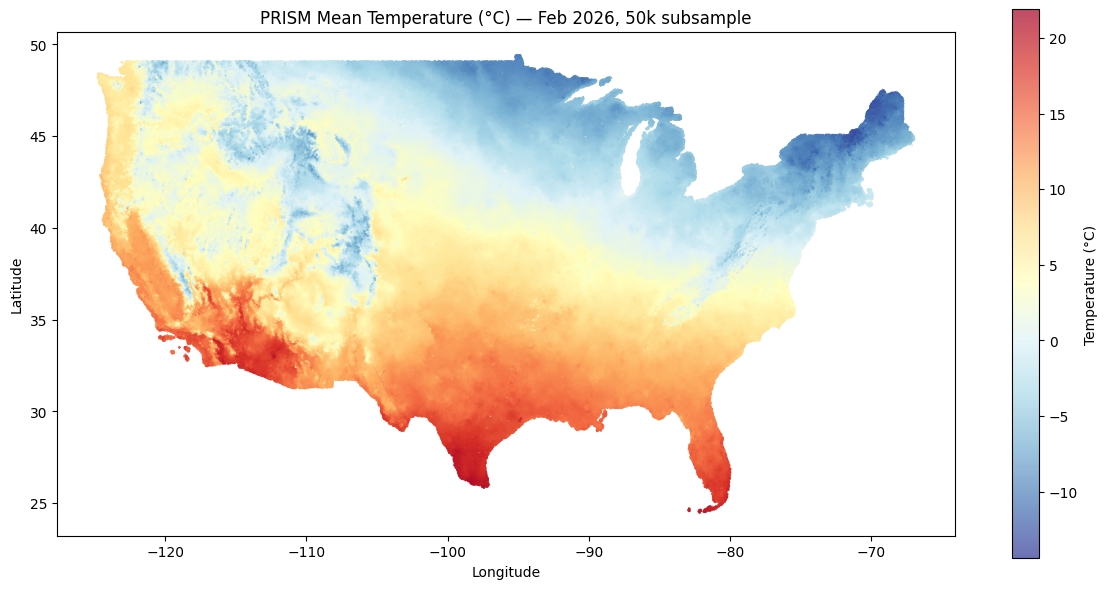

In [3]:
# Plot raw data
fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(x[:,0].numpy(), x[:,1].numpy(), c=y.numpy(), s=0.3,
                cmap='RdYlBu_r', alpha=0.7, rasterized=True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('PRISM Mean Temperature (°C) — Feb 2026, 50k subsample')
plt.colorbar(sc, ax=ax, label='Temperature (°C)')
ax.set_aspect(1.3)
plt.tight_layout()

In [4]:
# Normalize inputs to [0, 1] and standardize outputs
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"y mean={y.mean():.4f}, std={y.std():.4f}")

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=-0.0000, std=1.0000


In [5]:
EPSILON = 1e-1
kernel_type = 'SquaredExponential'
cg_tol = 1e-4

In [6]:
max_iters = 50
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.1)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol)
    optimizer.step()

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"iter {it:>3}  ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}")

print(f"Final: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}")

iter   0  ℓ=0.1752  σ_f²=1.105  σ_n²=0.181
iter  10  ℓ=0.09258  σ_f²=1.931  σ_n²=0.06802
iter  20  ℓ=0.04964  σ_f²=3.808  σ_n²=0.03244
iter  30  ℓ=0.025  σ_f²=6.477  σ_n²=0.02252
iter  40  ℓ=0.01528  σ_f²=9.127  σ_n²=0.01512
Final: ℓ=0.01176, σ_f²=11.62, σ_n²=0.0112


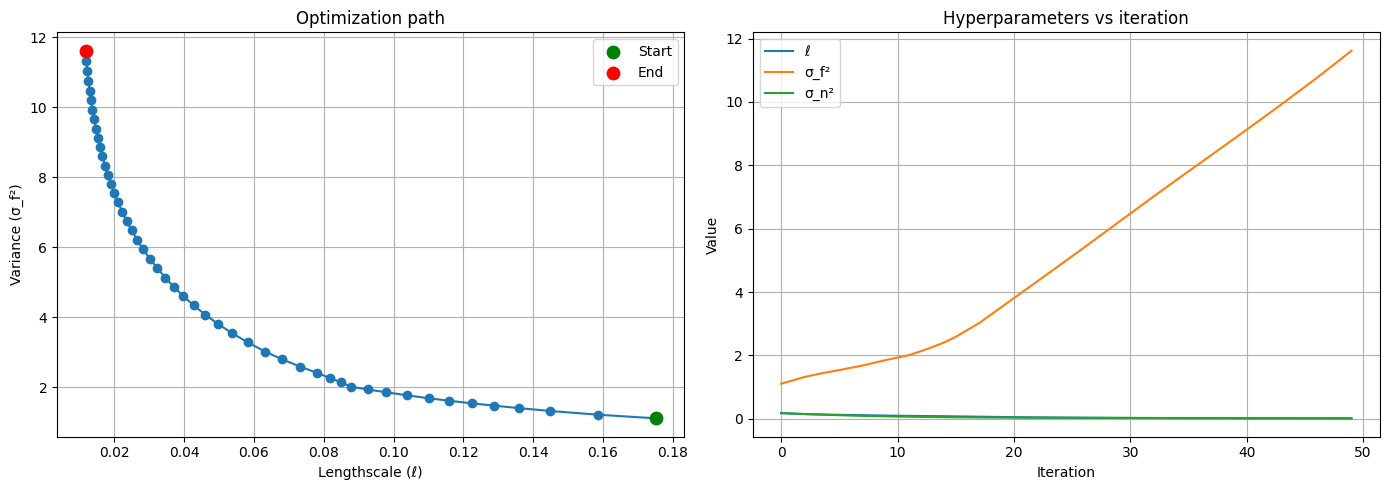

In [7]:
# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ℓ)')
ax1.set_ylabel('Variance (σ_f²)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='ℓ')
ax2.plot(training_log['iter'], training_log['variance'], label='σ_f²')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='σ_n²')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [8]:
# Predict posterior mean on a grid
grid_res = 200
g0 = torch.linspace(0, 1, grid_res, dtype=x.dtype)
g1 = torch.linspace(0, 1, grid_res, dtype=x.dtype)
G0, G1 = torch.meshgrid(g0, g1, indexing='ij')
x_new = torch.stack([G0.flatten(), G1.flatten()], dim=1)

mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

# Inverse transform back to original scales
mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res, grid_res)
lon_grid = (G0.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
lat_grid = (G1.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())

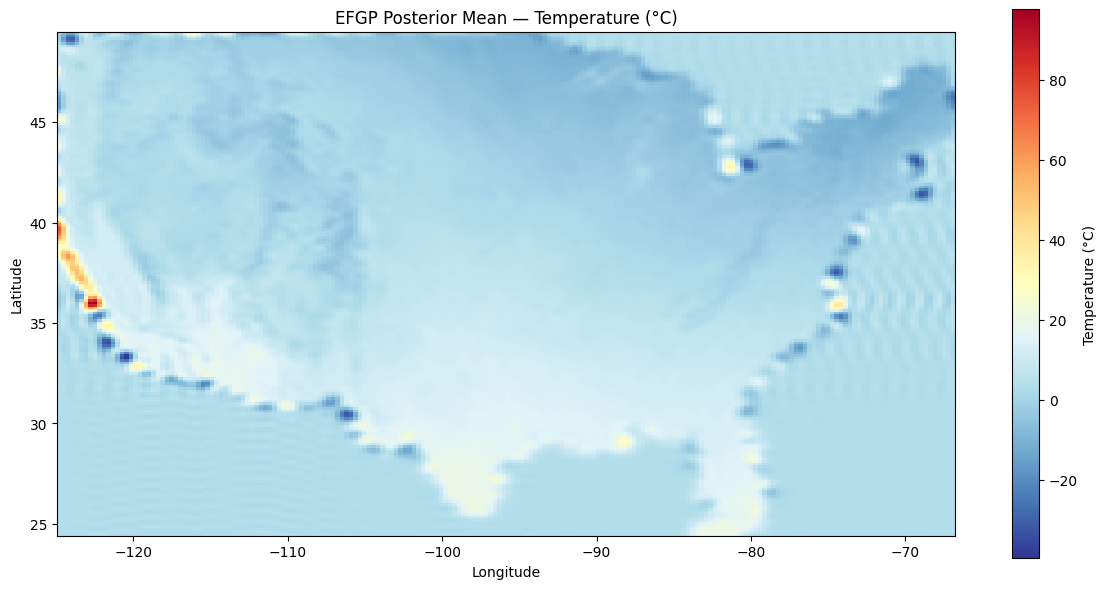

In [9]:
# Plot posterior mean
# Match the color scaling of the raw-data plot
vmin = y.detach().min().item()
vmax = y.detach().max().item()

fig, ax = plt.subplots(figsize=(12, 6))
pcm = ax.pcolormesh(lon_grid, lat_grid, mean_grid, cmap='RdYlBu_r',
                     shading='auto', rasterized=True, vmin=vmin, vmax=vmax)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('EFGP Posterior Mean — Temperature (°C)')
plt.colorbar(pcm, ax=ax, label='Temperature (°C)')
ax.set_aspect(1.3)
plt.tight_layout()